In [1]:
import freesasa

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from Bio import SeqIO

import glob

In [3]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_full.tsv.gz', sep='\t')
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t')

In [4]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [5]:
pdbs[:5]

['./../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000717275.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_001187505.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000376885.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000411155.1_A_processed.pdb']

In [6]:
def compute_delta_sasa_freesasa(pdb_file):
    """
    Compute delta SASA using FreeSASA
    """
    # Load structure
    structure = freesasa.Structure(pdb_file)
    
    # Calculate SASA for folded state
    folded_result = freesasa.calc(structure)
    
    # Get per-residue SASA
    classifier = freesasa.Classifier()
    folded_sasa_by_residue = {}
    
    for i in range(structure.nAtoms()):
        atom = structure.atomName(i)
        residue_number = structure.residueNumber(i)
        residue_name = structure.residueName(i)
        
        if residue_number not in folded_sasa_by_residue:
            folded_sasa_by_residue[residue_number] = {
                'name': residue_name,
                'sasa': 0.0
            }
        
        folded_sasa_by_residue[residue_number]['sasa'] += folded_result.atomArea(i)
    
    # Reference values (Tien et al. 2013, or Miller et al. 1987)
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    # Calculate delta SASA
    delta_sasa = {}
    for res_num, res_data in folded_sasa_by_residue.items():
        res_name = res_data['name']
        if res_name in reference_sasa:
            delta_sasa[res_num] = reference_sasa[res_name] - res_data['sasa']
    
    return delta_sasa

def compute_normalized_delta_sasa(pdb_file):
    """
    Compute normalized delta SASA (0 = fully buried, 1 = fully exposed)
    """
    delta_sasa = compute_delta_sasa_freesasa(pdb_file)
    
    # Reference SASA values
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    normalized_delta_sasa = {}
    for res_num, delta_val in delta_sasa.items():
        # Need to get residue name for normalization
        # This is simplified - you'd need to get actual residue name
        res_name = 'ALA'  # placeholder
        if res_name in reference_sasa:
            normalized_delta_sasa[res_num] = delta_val / reference_sasa[res_name]
    
    return normalized_delta_sasa

## outline
Compute a deltaSASA for the residues in each protein and see whether the average change of the residues is correlated with higher or lower thermostability

In [17]:
test_dataset = filtered.groupby('temp').apply(lambda x: x.sample(np.min([100, len(x)]), replace=False))

In [18]:
df_list = []
for p in pdbs:
    uid =  p.split('/')[-1].split('_A_')[0]
    if uid in test_dataset['uid'].unique():
        df_list.append(pd.Series(compute_normalized_delta_sasa(p), name=uid))

test_df = pd.concat(df_list, axis=1)
test_df.head()

,GB_GCA_001749745.1,RS_GCF_000427905.1,RS_GCF_000379025.1,RS_GCF_000023825.1,RS_GCF_000213255.1,RS_GCF_000242915.1,RS_GCF_000517025.1,RS_GCF_001418005.1,RS_GCF_000014725.1,RS_GCF_000178835.2,...,RS_GCF_902459735.1,RS_GCF_900536025.1,RS_GCF_900566055.1,RS_GCF_902459765.1,RS_GCF_900566075.1,RS_GCF_902459805.1,RS_GCF_902499555.1,RS_GCF_900606115.1,RS_GCF_902499125.1,RS_GCF_902804485.1
1,1.121268,NaN,1.253346,0.991487,1.155460,1.139857,1.115837,1.268971,1.169207,1.283976,...,1.314481,1.301405,1.284606,1.299036,1.245111,1.283554,0.797266,1.275181,1.314428,0.860278
2,1.295136,0.518896,1.431592,1.181297,1.329010,1.558389,1.416331,1.786367,1.454736,1.795096,...,1.443717,1.551883,1.826351,1.463084,1.814119,1.467270,1.011680,1.549162,1.448148,1.182927
3,1.540414,1.147235,1.558140,1.511628,1.527132,1.527132,1.556067,1.557991,1.522914,1.558140,...,1.558140,1.345457,1.348837,1.558140,1.348743,1.558140,1.511628,1.558140,1.558140,1.511628
4,1.348837,2.035079,1.527132,1.839351,1.348696,1.527132,1.348837,1.527132,1.520357,1.527132,...,1.503874,1.527132,1.347329,1.504616,1.346843,1.527132,1.518531,1.522790,1.519535,1.527132
5,1.842610,1.537511,1.547718,1.342239,1.548831,1.537654,1.543362,1.551198,1.533423,1.541451,...,1.541247,1.543162,1.542032,1.529617,1.543653,1.541362,1.340346,1.547677,1.542432,1.348113


<Axes: xlabel='None', ylabel='temp'>

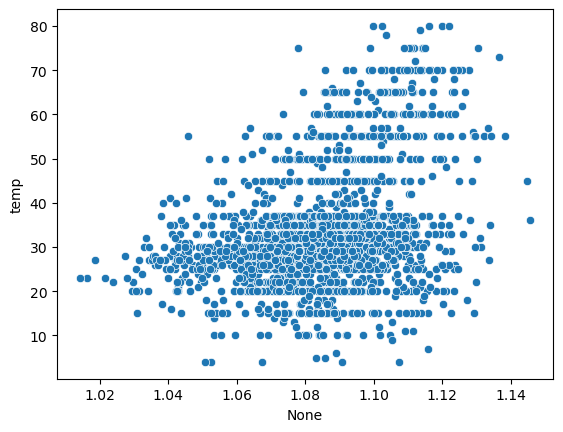

In [19]:
sns.scatterplot(x=test_df.mean(), y=test_dataset.set_index('uid')['temp'])

In [20]:
with open('./../data/20240122_all_adks_filtered_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

aln_df = pd.concat(lines, axis=1).T

def translate_with_gaps(nuc_seq):
    return [
        str(Seq(codon).translate()) if '-' not in codon and len(codon) == 3 else '-'
        for codon in [nuc_seq[i:i+3] for i in range(0, len(nuc_seq), 3)]
    ]

# aln_df = pd.concat([aln_df, anc_trim_df]).fillna('-')

aln_df.head()

aln_df.index = [s.split('|')[1] for s in aln_df.index]

In [28]:
# Convert to numpy for speed
sasa_array = test_df.T.values

# Handle NaN values by filling with column means
col_means = np.nanmean(sasa_array, axis=0)
sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)

window_averages = uniform_filter1d(
    sasa_filled, 
    size=39, 
    axis=1, 
    mode='constant'
)

In [31]:
# sns.histplot(
pd.DataFrame(data=window_averages, index=test_df.T.index).apply(lambda x: pearsonr(x, test_dataset.set_index('uid')['temp'].reindex(index=x.index))[0], axis=0).idxmax()
            # )

192

<Axes: xlabel='192', ylabel='temp'>

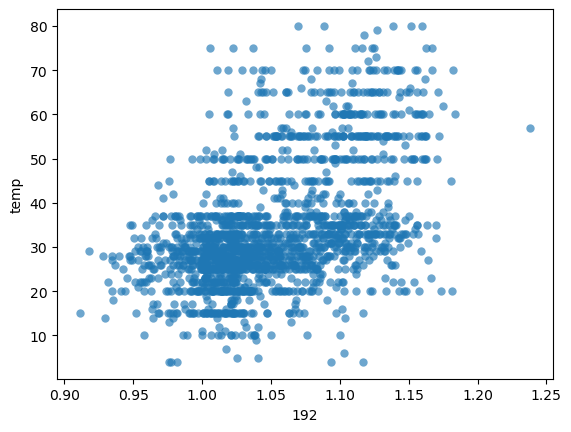

In [37]:
sns.scatterplot(x=pd.DataFrame(data=window_averages, index=test_df.T.index).loc[:, 192],
                y= test_dataset.set_index('uid')['temp'], linewidth=0, alpha=0.65)

In [50]:
sasa_filled

array([[1.25334636, 1.43159196, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.3358836 , 1.76934596, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.15546046, 1.32901012, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       ...,
       [1.28355352, 1.46726975, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.79726611, 1.01167984, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.86027754, 1.18292725, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583]])

In [32]:

from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SASAWindowAnalyzer:
    """
    Efficiently analyze SASA windows for correlation with traits
    """
    
    def __init__(self, sasa_df: pd.DataFrame, traits: pd.Series, 
                 max_window_size: int = 50, min_window_size: int = 3):
        """
        Initialize analyzer
        
        Parameters:
        -----------
        sasa_df : pd.DataFrame
            DataFrame with proteins as rows, residue positions as columns
            Contains delta SASA values
        traits : pd.Series
            Series with protein names as index, trait values as values
        max_window_size : int
            Maximum window size to test
        min_window_size : int
            Minimum window size to test
        """
        self.sasa_df = sasa_df
        self.traits = traits
        self.max_window_size = max_window_size
        self.min_window_size = min_window_size
        
        # Align data
        common_proteins = list(set(sasa_df.index) & set(traits.index))
        self.sasa_df = sasa_df.loc[common_proteins]
        self.traits = traits.loc[common_proteins]
        
        # Results storage
        self.results = []
        self.best_windows = {}
        
    def compute_sliding_windows_vectorized(self, window_size: int) -> np.ndarray:
        """
        Compute all sliding window averages efficiently using convolution
        
        Parameters:
        -----------
        window_size : int
            Size of sliding window
            
        Returns:
        --------
        np.ndarray
            Array of shape (n_proteins, n_positions - window_size + 1)
            Each element is the average SASA for that window
        """
        # Convert to numpy for speed
        sasa_array = self.sasa_df.values
        
        # Handle NaN values by filling with column means
        col_means = np.nanmean(sasa_array, axis=0)
        sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)
        
        # Use uniform_filter1d for efficient sliding window computation
        # This is equivalent to convolution but faster
        window_averages = uniform_filter1d(
            sasa_filled, 
            size=window_size, 
            axis=1, 
            mode='constant'
        )
        
        # Trim to valid windows only
        valid_positions = sasa_filled.shape[1] - window_size + 1
        return window_averages[:, :valid_positions]
    
    def analyze_window_size(self, window_size: int, correlation_method: str = 'pearson') -> Dict:
        """
        Analyze all windows of a given size
        
        Parameters:
        -----------
        window_size : int
            Size of window to analyze
        correlation_method : str
            'pearson' or 'spearman'
            
        Returns:
        --------
        Dict containing results for this window size
        """
        # Get all window averages
        window_averages = self.compute_sliding_windows_vectorized(window_size)
        
        # Compute correlations for each window position
        n_windows = window_averages.shape[1]
        correlations = np.zeros(n_windows)
        p_values = np.zeros(n_windows)
        
        trait_values = self.traits.values
        
        for i in range(n_windows):
            window_sasa = window_averages[:, i]
            
            # Remove any remaining NaN values
            valid_mask = ~np.isnan(window_sasa) & ~np.isnan(trait_values)
            
            if np.sum(valid_mask) > 3:  # Need at least 4 points for correlation
                if correlation_method == 'pearson':
                    corr, p_val = pearsonr(window_sasa[valid_mask], trait_values[valid_mask])
                else:
                    corr, p_val = spearmanr(window_sasa[valid_mask], trait_values[valid_mask])
                
                correlations[i] = corr
                p_values[i] = p_val
            else:
                correlations[i] = np.nan
                p_values[i] = np.nan
        
        # Find best window for this size
        abs_correlations = np.abs(correlations)
        best_idx = np.nanargmax(abs_correlations)
        
        return {
            'window_size': window_size,
            'correlations': correlations,
            'p_values': p_values,
            'best_correlation': correlations[best_idx],
            'best_p_value': p_values[best_idx],
            'best_position': best_idx,
            'best_window_range': (best_idx, best_idx + window_size - 1)
        }
    
    def run_full_analysis(self, correlation_method: str = 'pearson', 
                         step_size: int = 1) -> pd.DataFrame:
        """
        Run analysis across all window sizes
        
        Parameters:
        -----------
        correlation_method : str
            'pearson' or 'spearman'
        step_size : int
            Step size for window sizes (1 = test every size)
            
        Returns:
        --------
        pd.DataFrame with results summary
        """
        print(f"Analyzing windows from {self.min_window_size} to {self.max_window_size}")
        
        self.results = []
        
        window_sizes = range(self.min_window_size, self.max_window_size + 1, step_size)
        
        for window_size in tqdm(window_sizes, desc="Window sizes"):
            if window_size > self.sasa_df.shape[1]:
                continue
                
            result = self.analyze_window_size(window_size, correlation_method)
            self.results.append(result)
            
            # Store best windows
            self.best_windows[window_size] = result
        
        # Create summary DataFrame
        summary_data = []
        for result in self.results:
            summary_data.append({
                'window_size': result['window_size'],
                'best_correlation': result['best_correlation'],
                'best_p_value': result['best_p_value'],
                'best_position': result['best_position'],
                'best_start': result['best_window_range'][0],
                'best_end': result['best_window_range'][1]
            })
        
        return pd.DataFrame(summary_data)
    
    def get_top_windows(self, n_top: int = 10) -> pd.DataFrame:
        """
        Get top N windows across all sizes
        
        Parameters:
        -----------
        n_top : int
            Number of top windows to return
            
        Returns:
        --------
        pd.DataFrame with top windows
        """
        all_windows = []
        
        for result in self.results:
            window_size = result['window_size']
            correlations = result['correlations']
            p_values = result['p_values']
            
            for i, (corr, p_val) in enumerate(zip(correlations, p_values)):
                if not np.isnan(corr):
                    all_windows.append({
                        'window_size': window_size,
                        'start_position': i,
                        'end_position': i + window_size - 1,
                        'correlation': corr,
                        'abs_correlation': abs(corr),
                        'p_value': p_val
                    })
        
        df = pd.DataFrame(all_windows)
        return df.nlargest(n_top, 'abs_correlation')
    
    def plot_results(self, figsize: Tuple[int, int] = (15, 10)):
        """
        Plot analysis results
        """
        if not self.results:
            print("No results to plot. Run analysis first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Plot 1: Best correlation vs window size
        window_sizes = [r['window_size'] for r in self.results]
        best_corrs = [r['best_correlation'] for r in self.results]
        
        axes[0, 0].plot(window_sizes, best_corrs, 'bo-')
        axes[0, 0].set_xlabel('Window Size')
        axes[0, 0].set_ylabel('Best Correlation')
        axes[0, 0].set_title('Best Correlation vs Window Size')
        axes[0, 0].grid(True)
        
        # Plot 2: Best position vs window size
        best_positions = [r['best_position'] for r in self.results]
        axes[0, 1].plot(window_sizes, best_positions, 'ro-')
        axes[0, 1].set_xlabel('Window Size')
        axes[0, 1].set_ylabel('Best Position')
        axes[0, 1].set_title('Best Position vs Window Size')
        axes[0, 1].grid(True)
        
        # Plot 3: Heatmap of correlations (for selected window sizes)
        selected_sizes = window_sizes[::max(1, len(window_sizes)//10)]  # Sample ~10 sizes
        heatmap_data = []
        
        for size in selected_sizes:
            result = self.best_windows[size]
            # Pad correlations to same length
            corrs = result['correlations']
            max_len = max(len(r['correlations']) for r in self.results)
            padded_corrs = np.pad(corrs, (0, max_len - len(corrs)), constant_values=np.nan)
            heatmap_data.append(padded_corrs)
        
        if heatmap_data:
            heatmap_array = np.array(heatmap_data)
            im = axes[1, 0].imshow(heatmap_array, aspect='auto', cmap='RdBu_r')
            axes[1, 0].set_xlabel('Position')
            axes[1, 0].set_ylabel('Window Size')
            axes[1, 0].set_title('Correlation Heatmap')
            axes[1, 0].set_yticks(range(len(selected_sizes)))
            axes[1, 0].set_yticklabels(selected_sizes)
            plt.colorbar(im, ax=axes[1, 0])

        for site in [62, 209, 201, 25, 2, 205, 179, 160]:
            axes[1, 0].axvline(site, color='k')
        
        # Plot 4: P-value distribution
        all_p_values = []
        for result in self.results:
            p_vals = result['p_values']
            all_p_values.extend(p_vals[~np.isnan(p_vals)])
        
        if all_p_values:
            axes[1, 1].hist(all_p_values, bins=50, alpha=0.7)
            axes[1, 1].axvline(x=0.05, color='red', linestyle='--', label='p=0.05')
            axes[1, 1].set_xlabel('P-value')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('P-value Distribution')
            axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_window_features(self, top_n: int = 10) -> pd.DataFrame:
        """
        Extract top windows as features for downstream modeling
        
        Parameters:
        -----------
        top_n : int
            Number of top windows to extract as features
            
        Returns:
        --------
        pd.DataFrame with proteins as rows, window features as columns
        """
        top_windows = self.get_top_windows(top_n)
        
        features = []
        feature_names = []
        
        for _, window in top_windows.iterrows():
            window_size = window['window_size']
            start_pos = int(window['start_position'])
            end_pos = int(window['end_position'])
            
            # Compute window averages for this specific window
            window_avg = self.sasa_df.iloc[:, start_pos:end_pos+1].mean(axis=1)
            
            features.append(window_avg)
            feature_names.append(f'window_{start_pos}_{end_pos}_size{window_size}')
        
        feature_df = pd.DataFrame(np.array(features).T, 
                                index=self.sasa_df.index, 
                                columns=feature_names)
        
        return feature_df

# # Example usage
# def example_usage():
#     """
#     Example of how to use the SASAWindowAnalyzer
#     """
#     # Create sample data
#     np.random.seed(42)
#     n_proteins = 100
#     n_residues = 200
    
#     # Generate synthetic SASA data
#     sasa_data = np.random.randn(n_proteins, n_residues)
    
#     # Add some regional patterns
#     sasa_data[:, 50:70] += np.random.randn(n_proteins, 20) * 2  # High variance region
#     sasa_data[:, 120:140] -= 1  # Consistently buried region
    
#     # Create DataFrames
#     protein_names = [f'protein_{i}' for i in range(n_proteins)]
#     sasa_df = pd.DataFrame(sasa_data, index=protein_names)
    
#     # Generate synthetic trait correlated with specific regions
#     trait_values = (sasa_data[:, 55:65].mean(axis=1) + 
#                    sasa_data[:, 125:135].mean(axis=1) + 
#                    np.random.randn(n_proteins) * 0.5)
#     traits = pd.Series(trait_values, index=protein_names)
    
#     # Run analysis
#     analyzer = SASAWindowAnalyzer(sasa_df, traits, max_window_size=30)
#     summary = analyzer.run_full_analysis()
    
#     print("Top 5 window sizes by correlation:")
#     print(summary.nlargest(5, 'best_correlation'))
    
#     print("\nTop 10 windows overall:")
#     top_windows = analyzer.get_top_windows(10)
#     print(top_windows)
    
#     # Plot results
#     analyzer.plot_results()
    
#     # Get features for modeling
#     window_features = analyzer.get_window_features(5)
#     print(f"\nWindow features shape: {window_features.shape}")
#     print(window_features.head())

Analyzing windows from 3 to 50


Window sizes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:09<00:00,  5.06it/s]


      window_size  start_position  end_position  correlation  abs_correlation  \
7790           35             190           224     0.490960         0.490960   
8670           39             192           230     0.487307         0.487307   
8012           36             191           226     0.483512         0.483512   
8011           36             190           225     0.482970         0.482970   
7569           34             191           224     0.481532         0.481532   
8887           40             192           231     0.481043         0.481043   
7568           34             190           223     0.480150         0.480150   
8230           37             189           225     0.477882         0.477882   
8452           38             192           229     0.477642         0.477642   
8453           38             193           230     0.476837         0.476837   
8449           38             189           226     0.476711         0.476711   
8231           37           

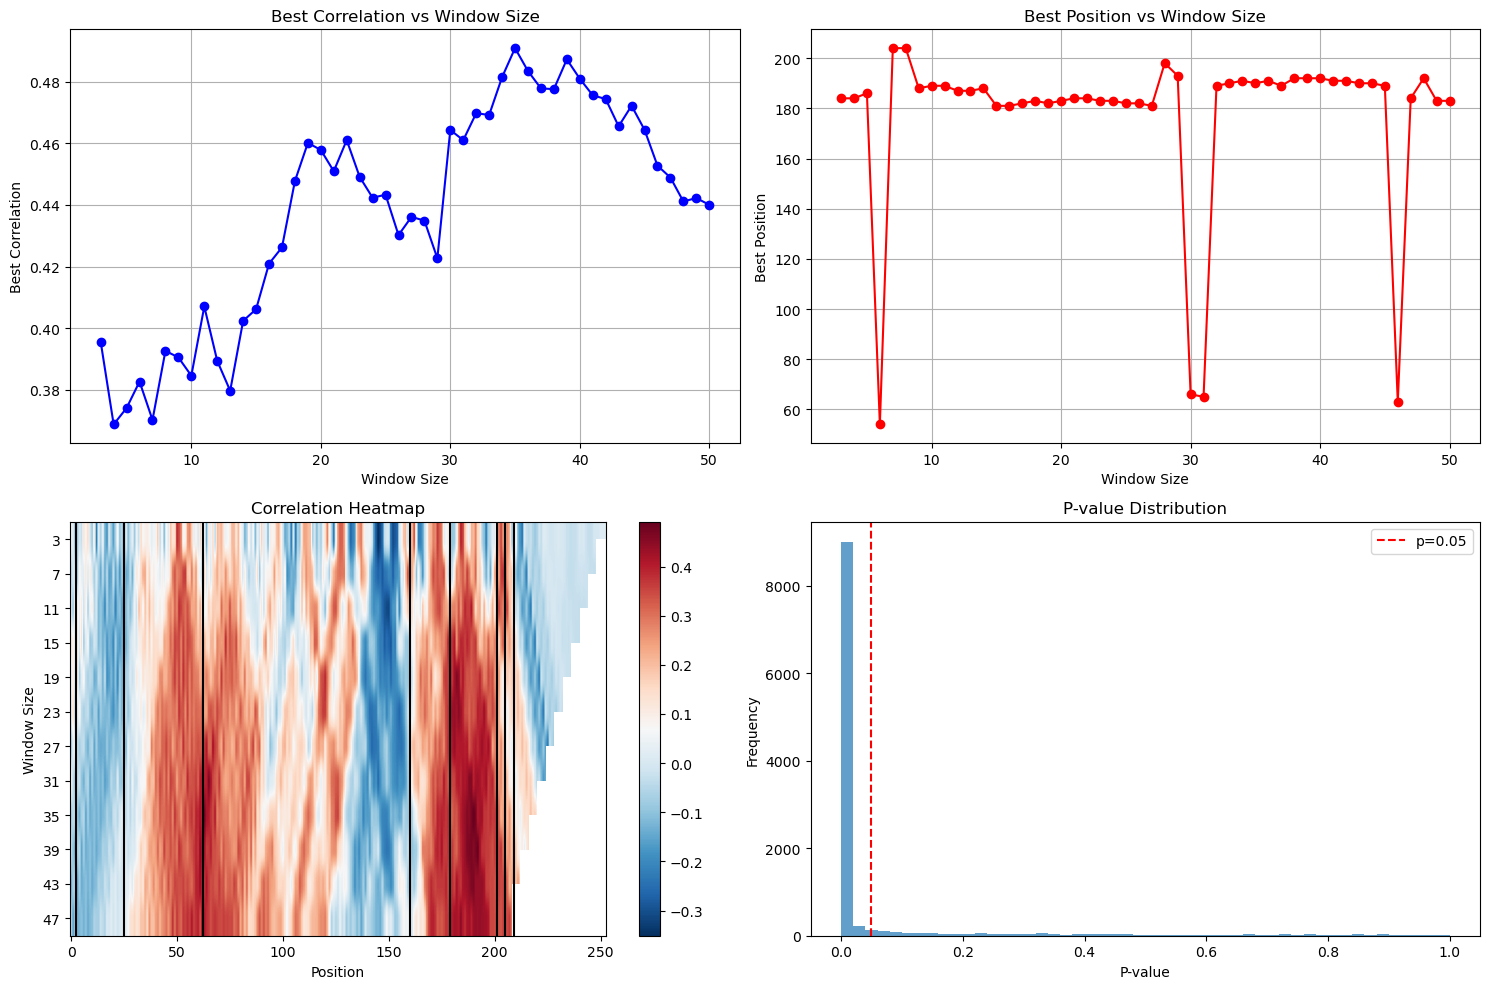

In [33]:
# # Load your data
# sasa_df = pd.read_csv('your_deltasasa_data.csv', index_col=0)  # proteins x residues
# traits = pd.read_csv('your_traits.csv', index_col=0)['trait_column']

# Initialize analyzer
analyzer = SASAWindowAnalyzer(
    sasa_df=test_df.T,
    traits=test_dataset.set_index('uid')['temp'],
    max_window_size=50,  # Adjust based on your protein lengths
    min_window_size=3
)

# Run full analysis
summary = analyzer.run_full_analysis(correlation_method='pearson')

# Get top windows
top_windows = analyzer.get_top_windows(20)
print(top_windows)

# Visualize results
analyzer.plot_results()

# Extract features for modeling
window_features = analyzer.get_window_features(10)

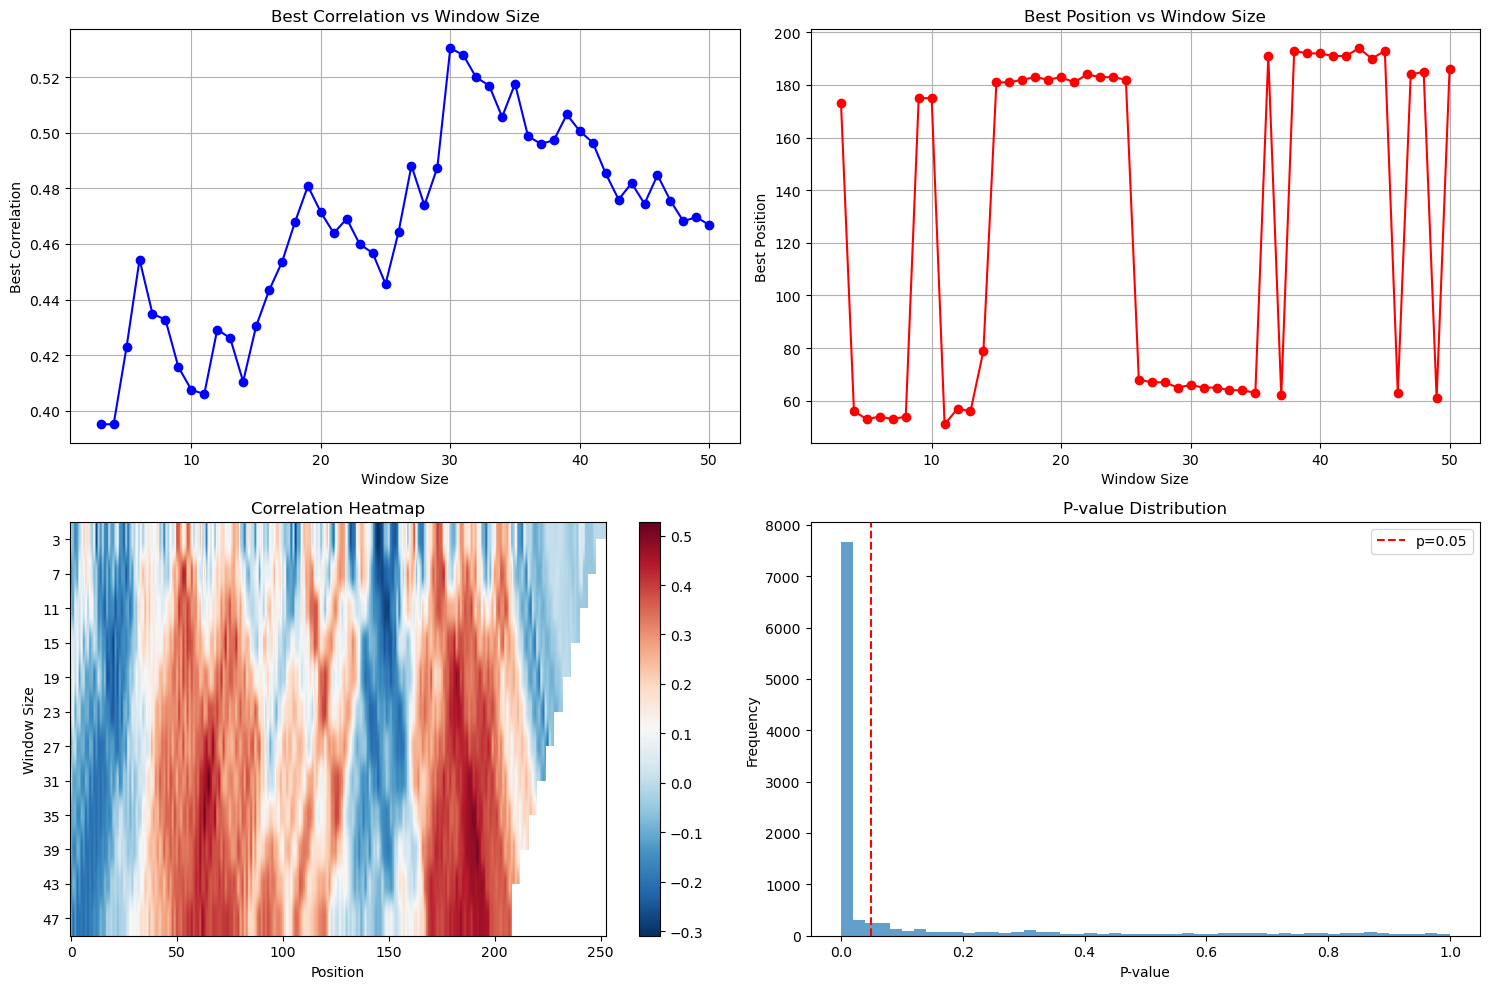

In [47]:
analyzer